# 🌌 Stellar Stream Detection: Inference & Error Analysis

**Master's Thesis (TFM) - Final Evaluation**

This notebook performs the **final inference and qualitative analysis** of the Deep U-Net model trained for Stellar Stream detection in low signal-to-noise ratio (SNR) environments.

### 🎯 Objectives
1.  **Model Restoration:** Load the best-performing model (`.keras`) with custom loss functions.
2.  **Quantitative Evaluation:** Compute intersection-over-Union (IoU), Precision, and Recall on the unseen Test Set.
3.  **Confusion Matrix:** Visualize pixel-wise classification errors.
4.  **Qualitative "Hard Mining":** Visual inspection of the best and worst predictions to understand model limitations.

---

In [8]:
# ==========================================
# 1. ENVIRONMENT SETUP & CONFIGURATION
# ==========================================
import os
import gc
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
from astropy.io import fits
from tqdm.notebook import tqdm

# Plotting Style
sns.set_style("whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.figsize': (10, 6),
    'figure.dpi': 150, 
    'savefig.dpi': 300,
})

# Configuration Constants
IMG_SIZE = (128, 128)
N_CHANNELS = 4
N_CLASSES = 3
SEED = 42

print("✅ Visualization Environment Configured.")
print(f"🖥️ GPU Available: {len(tf.config.list_physical_devices('GPU'))}")

✅ Visualization Environment Configured.
🖥️ GPU Available: 1


## 🧠 Model Restoration
Loads the trained `.keras` model with its custom loss functions (`dice_coef`, `final_loss`). These must be re-defined identically to the training environment for Keras to deserialize the model correctly.

In [9]:
# ==========================================
# 2. MODEL LOADING & CUSTOM OBJECTS
# ==========================================

# Define custom metrics/losses used during training (Required for Keras loading)
def dice_coef(y_true, y_pred, smooth=1e-6):
    """Dice Coefficient Metric defined during training."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred, axis=(1, 2))
    union = tf.reduce_sum(y_true, axis=(1, 2)) + tf.reduce_sum(y_pred, axis=(1, 2))
    return tf.reduce_mean((2. * intersection + smooth) / (union + smooth))

def final_loss(y_true, y_pred):
    """Placeholder for the custom loss function."""
    pass 



# Path to the trained model (Adjust based on your Input data structure)
# Note: Ensure you added the Training Notebook Output as a Data Source
MODEL_PATH = '/kaggle/input/goat/tensorflow2/keras/1/best_model_final.keras'

if not os.path.exists(MODEL_PATH):
    # Fallback search if path is different
    print(f"⚠️ Model not found at {MODEL_PATH}. Searching directory...")
    for root, dirs, files in os.walk('/kaggle/input'):
        for file in files:
            if file.endswith('best_model_hard_mining.keras'):
                MODEL_PATH = os.path.join(root, file)
                print(f"   -> Found model at: {MODEL_PATH}")


try:
    print(f"🔄 Loading model from: {MODEL_PATH}...")
    model = load_model(MODEL_PATH, custom_objects={'dice_metric': dice_coef, 'hybrid_loss': final_loss})
    print("🏆 Model loaded successfully.")
    print(f"   Input Shape: {model.input_shape}")
    print(f"   Output Shape: {model.output_shape}")
except Exception as e:
    print(f"❌ Error loading model: {e}")
    print("   Please verify the file path and that 'dice_coef' matches the training metric.")





🔄 Loading model from: /kaggle/input/goat/tensorflow2/keras/1/best_model_final.keras...
🏆 Model loaded successfully.
   Input Shape: (None, 128, 128, 4)
   Output Shape: (None, 128, 128, 3)


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 150 variables whereas the saved optimizer has 154 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [10]:
# ==========================================
# 3. TEST DATA INGESTION
# ==========================================

def load_and_process_dataset(dataset_source):
    """
    Robust data loader matching the training preprocessing pipeline.
    """
    if isinstance(dataset_source, str):
        dataset_paths = [dataset_source]
    else:
        dataset_paths = dataset_source

    img_paths, mask_paths = [], []
    
    print("🔍 Scanning dataset directories...")
    for root_path in dataset_paths:
        if not os.path.exists(root_path): continue
            
        for root, dirs, files in os.walk(root_path):
            if 'images' in os.path.basename(root) or root.endswith('images'):
                mask_root = root.replace('images', 'masks')
                files_fits = sorted([f for f in files if f.endswith(('.fits', '.fit'))])
                
                for f in files_fits:
                    i_p = os.path.join(root, f)
                    # Robust mask finding
                    possible_names = [f, f.replace('image_', 'mask_'), f.replace('img_', 'mask_')]
                    m_p = None
                    for name in possible_names:
                        test_path = os.path.join(mask_root, name)
                        if os.path.exists(test_path):
                            m_p = test_path
                            break
                    if m_p:
                        img_paths.append(i_p)
                        mask_paths.append(m_p)
    
    n_samples = len(img_paths)
    print(f"📦 Found {n_samples} samples. Loading into RAM...")
    
    X = np.empty((n_samples, *IMG_SIZE, N_CHANNELS), dtype=np.float32)
    Y = np.empty((n_samples, *IMG_SIZE, N_CLASSES), dtype=np.float32)

    for i, (imp, mskp) in enumerate(tqdm(zip(img_paths, mask_paths), total=n_samples, desc="Loading")):
        try:
            with fits.open(imp, memmap=False) as hdul:
                data = hdul[0].data.astype(np.float32)
                if data.ndim == 3 and data.shape[0] == N_CHANNELS: data = np.moveaxis(data, 0, -1)
                # Robust Norm
                p1, p99 = np.percentile(data, 1), np.percentile(data, 99)
                if p99 > p1: data = (data - p1) / (p99 - p1)
                X[i] = np.clip(data, 0, 1)

            with fits.open(mskp, memmap=False) as hdul:
                mask = hdul[0].data.astype(np.uint8)
                Y[i] = to_categorical(mask, num_classes=N_CLASSES)
        except: pass
            
    return X, Y

# Execution
DATASET_PATH = '/kaggle/input/synthetic-dataset' # Verify this path
X_full, Y_full = load_and_process_dataset(DATASET_PATH)

# Replicating the Train/Val/Test Split
# We use the same seed (42) to ensure we test on the exact same validation set used during training
from sklearn.model_selection import train_test_split
_, X_test, _, Y_test = train_test_split(X_full, Y_full, test_size=0.15, random_state=SEED, shuffle=True)

# Clean up RAM
del X_full, Y_full
gc.collect()

print(f"📊 Test Set Prepared: {len(X_test)} samples.")

🔍 Scanning dataset directories...
📦 Found 20000 samples. Loading into RAM...


Loading:   0%|          | 0/20000 [00:00<?, ?it/s]

📊 Test Set Prepared: 3000 samples.


## 🚀 Test-Time Augmentation (TTA) Inference
Standard inference is enhanced with **4× TTA**: the model predicts on the original image plus three geometric flips (horizontal, vertical, both). The four probability maps are averaged to produce smoother, more robust segmentation masks — particularly beneficial at structure boundaries.

In [11]:
# ==========================================
# 4. TTA INFERENCE & QUANTITATIVE ANALYSIS
# ==========================================

def predict_with_tta(model, X_data, batch_size=16):
    """
    Test Time Augmentation (TTA) Engine.
    Performs prediction on 4 variations of the input and averages the results
    to smooth out noise and improve boundary precision.
    Variations: Original, Flip Horizontal, Flip Vertical, Flip Both.
    """
    print(f"🚀 Starting TTA (4x) Inference on {len(X_data)} samples...")
    
    # 1. Original
    p1 = model.predict(X_data, batch_size=batch_size, verbose=0)
    
    # 2. Flip Horizontal (Width axis=2)
    X_fh = np.flip(X_data, axis=2)
    p2 = model.predict(X_fh, batch_size=batch_size, verbose=0)
    p2 = np.flip(p2, axis=2) # Restore orientation
    
    # 3. Flip Vertical (Height axis=1)
    X_fv = np.flip(X_data, axis=1)
    p3 = model.predict(X_fv, batch_size=batch_size, verbose=0)
    p3 = np.flip(p3, axis=1) # Restore orientation
    
    # 4. Flip Both (Horizontal + Vertical)
    X_fhv = np.flip(X_data, axis=(1, 2))
    p4 = model.predict(X_fhv, batch_size=batch_size, verbose=0)
    p4 = np.flip(p4, axis=(1, 2)) # Restore orientation
    
    # Average Consensus
    print("✅ merging predictions...")
    return (p1 + p2 + p3 + p4) / 4.0

# --- EXECUTION ---

# Run Inference with TTA (Replaces standard model.predict)
preds = predict_with_tta(model, X_test, batch_size=16)

# Flatten for pixel-wise metrics
y_true_flat = np.argmax(Y_test, axis=-1).flatten()
y_pred_flat = np.argmax(preds, axis=-1).flatten()

# Compute Confusion Matrix
print("🔄 Calculating Confusion Matrix (this may take a moment)...")
cm = confusion_matrix(y_true_flat, y_pred_flat, labels=[0, 1, 2])

# Metrics per Class
intersection = np.diag(cm)
union = cm.sum(axis=1) + cm.sum(axis=0) - intersection
iou = intersection / (union + 1e-10)
precision = intersection / (cm.sum(axis=0) + 1e-10)
recall = intersection / (cm.sum(axis=1) + 1e-10)
f1_score = 2 * (precision * recall) / (precision + recall + 1e-10)

# Create Professional DataFrame
class_names = ['Background', 'Stream', 'Cirrus']
metrics_df = pd.DataFrame({
    'Class': class_names,
    'IoU': iou,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1_score,
    'Support (Pixels)': cm.sum(axis=1)
})

print("\n🏆 FINAL PERFORMANCE REPORT (WITH TTA):")
# Apply formatting only to numeric columns to avoid errors
numeric_cols = ['IoU', 'Precision', 'Recall', 'F1-Score']
display(metrics_df.style.background_gradient(cmap='Greens', subset=['IoU', 'F1-Score'])
                   .format("{:.4f}", subset=numeric_cols))

# Save to CSV for the Thesis
metrics_df.to_csv('final_test_metrics_TTA.csv', index=False)

🚀 Starting TTA (4x) Inference on 3000 samples...
✅ merging predictions...
🔄 Calculating Confusion Matrix (this may take a moment)...

🏆 FINAL PERFORMANCE REPORT (WITH TTA):


,Class,IoU,Precision,Recall,F1-Score,Support (Pixels)
0,Background,0.9932,0.9967,0.9964,0.9966,40963075
1,Stream,0.8427,0.9014,0.9283,0.9147,957755
2,Cirrus,0.9686,0.9850,0.9831,0.9841,7231170


## 📊 Baseline Comparison (Without TTA)
For completeness, we also compute the standard (non-augmented) metrics to quantify the exact improvement that TTA provides over raw model inference.

In [ ]:
# ==========================================
# 5. QUANTITATIVE PERFORMANCE ANALYSIS
# ==========================================

print("🧮 Running Inference on Test Set...")
preds = model.predict(X_test, batch_size=16, verbose=1)

# Flatten for pixel-wise metrics
y_true_flat = np.argmax(Y_test, axis=-1).flatten()
y_pred_flat = np.argmax(preds, axis=-1).flatten()

# Compute Confusion Matrix
print("🔄 Calculating Confusion Matrix (this may take a moment)...")
cm2 = confusion_matrix(y_true_flat, y_pred_flat, labels=[0, 1, 2])

# Metrics per Class
intersection = np.diag(cm2)
union = cm2.sum(axis=1) + cm2.sum(axis=0) - intersection
iou = intersection / (union + 1e-10)
precision = intersection / (cm2.sum(axis=0) + 1e-10)
recall = intersection / (cm2.sum(axis=1) + 1e-10)
f1_score = 2 * (precision * recall) / (precision + recall + 1e-10)

# Create Professional DataFrame
class_names = ['Background', 'Stream', 'Cirrus']
metrics_df = pd.DataFrame({
    'Class': class_names,
    'IoU': iou,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1_score,
    'Support (Pixels)': cm2.sum(axis=1)
})

print("\n🏆 FINAL PERFORMANCE REPORT:")
numeric_cols = ['IoU', 'Precision', 'Recall', 'F1-Score']
styled_df = metrics_df.style.background_gradient(cmap='Greens', subset=['IoU', 'F1-Score'])\
                            .format("{:.4f}", subset=numeric_cols)
display(styled_df)

# Save to CSV for the Thesis
metrics_df.to_csv('final_test_metrics.csv', index=False)

🧮 Running Inference on Test Set...
188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step
🔄 Calculating Confusion Matrix (this may take a moment)...

🏆 FINAL PERFORMANCE REPORT:


,Class,IoU,Precision,Recall,F1-Score,Support (Pixels)
0,Background,0.9927,0.9966,0.9962,0.9964,40963075
1,Stream,0.8326,0.8940,0.9239,0.9087,957755
2,Cirrus,0.9670,0.9843,0.9822,0.9832,7231170


✅ Confusion Matrix saved to: /kaggle/working/tfm_results_final/confusion_matrix_final.png


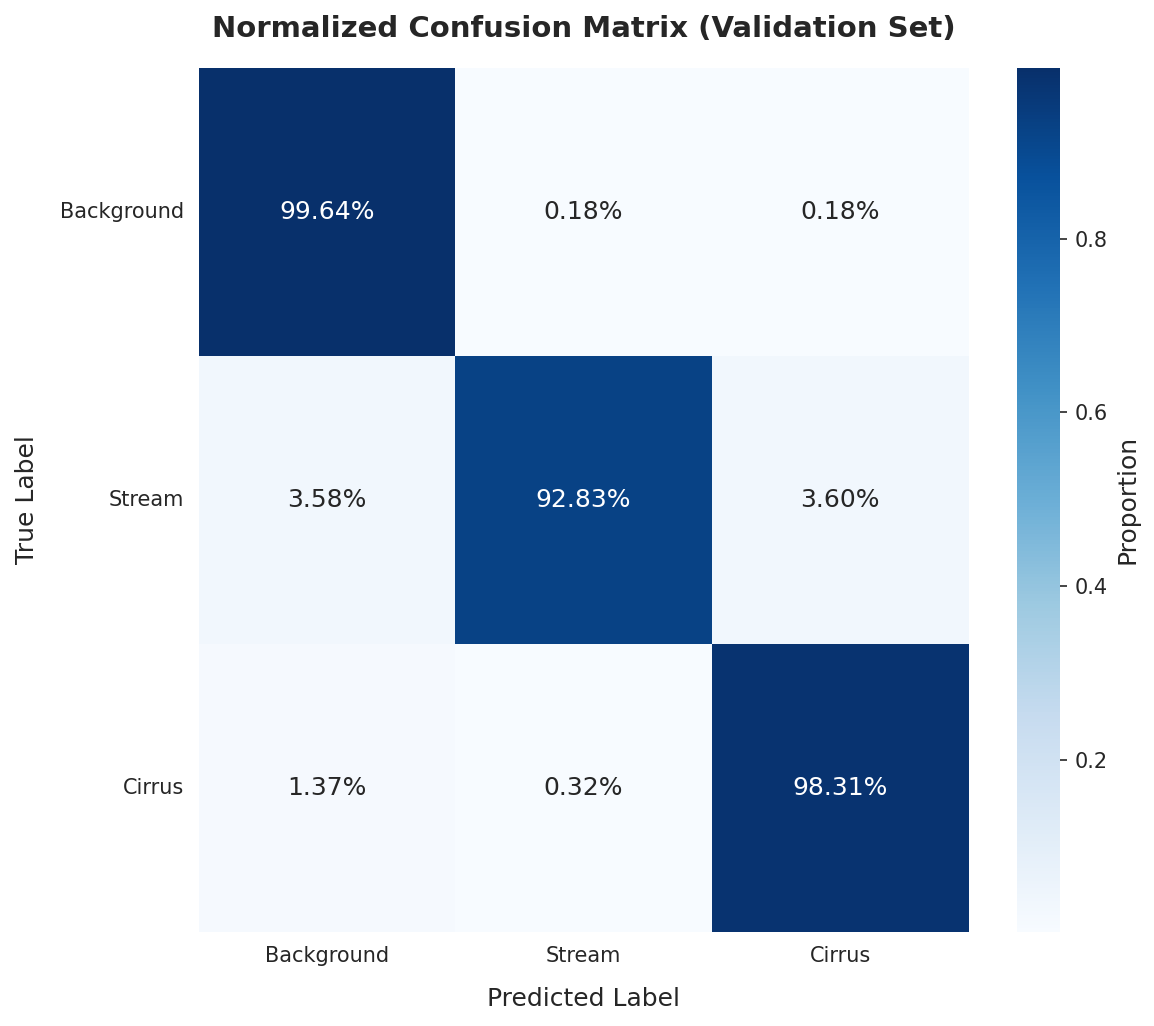

5409

In [13]:
# ==========================================
# 6. VISUAL CONFUSION MATRIX 
# ==========================================
import os
import matplotlib.pyplot as plt
import seaborn as sns
import gc

# 1. Define Output Directory (Ensures image is included in the final ZIP)
RESULTS_DIR = '/kaggle/working/tfm_results_final'
if not os.path.exists(RESULTS_DIR):
    os.makedirs(RESULTS_DIR)

# 2. Define Class Names (Ensure these match your Config)
class_names = ['Background', 'Stream', 'Cirrus']

# 3. Normalize Matrix (Row-wise: True Class distribution)
# We use the 'cm' variable calculated in the previous step
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# 4. Generate Professional Plot
plt.figure(figsize=(8, 7))
sns.heatmap(
    cm_norm, 
    annot=True, 
    fmt='.2%', 
    cmap='Blues', 
    cbar=True,
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={"size": 12},  # Larger font for numbers
    cbar_kws={'label': 'Proportion'}
)

plt.title('Normalized Confusion Matrix (Validation Set)', fontweight='bold', fontsize=14, pad=15)
plt.xlabel('Predicted Label', fontsize=12, labelpad=10)
plt.ylabel('True Label', fontsize=12, labelpad=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()

# 5. Save to Results Directory
save_path = os.path.join(RESULTS_DIR, 'confusion_matrix_final.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ Confusion Matrix saved to: {save_path}")

plt.show()

# 6. Memory Cleanup
# Uses try/except to handle potential variable name variations safely
try:
    del y_true_f, y_pred_f, cm, cm_norm
except NameError:
    try:
        del y_true_flat, y_pred_flat
    except:
        pass
        
gc.collect()

## 🔬 Qualitative Analysis & Hard Mining
The final section performs a **visual forensic analysis**:
1. **Best Cases:** Images where the model achieves near-perfect Stream IoU — validating that the architecture can recover faint structures.
2. **Worst Cases (Hard Mining):** Images where the model struggles the most — providing critical insights for future improvements and thesis discussion.

🌟 TOP 3 BEST PREDICTIONS (High Fidelity Stream Recovery):


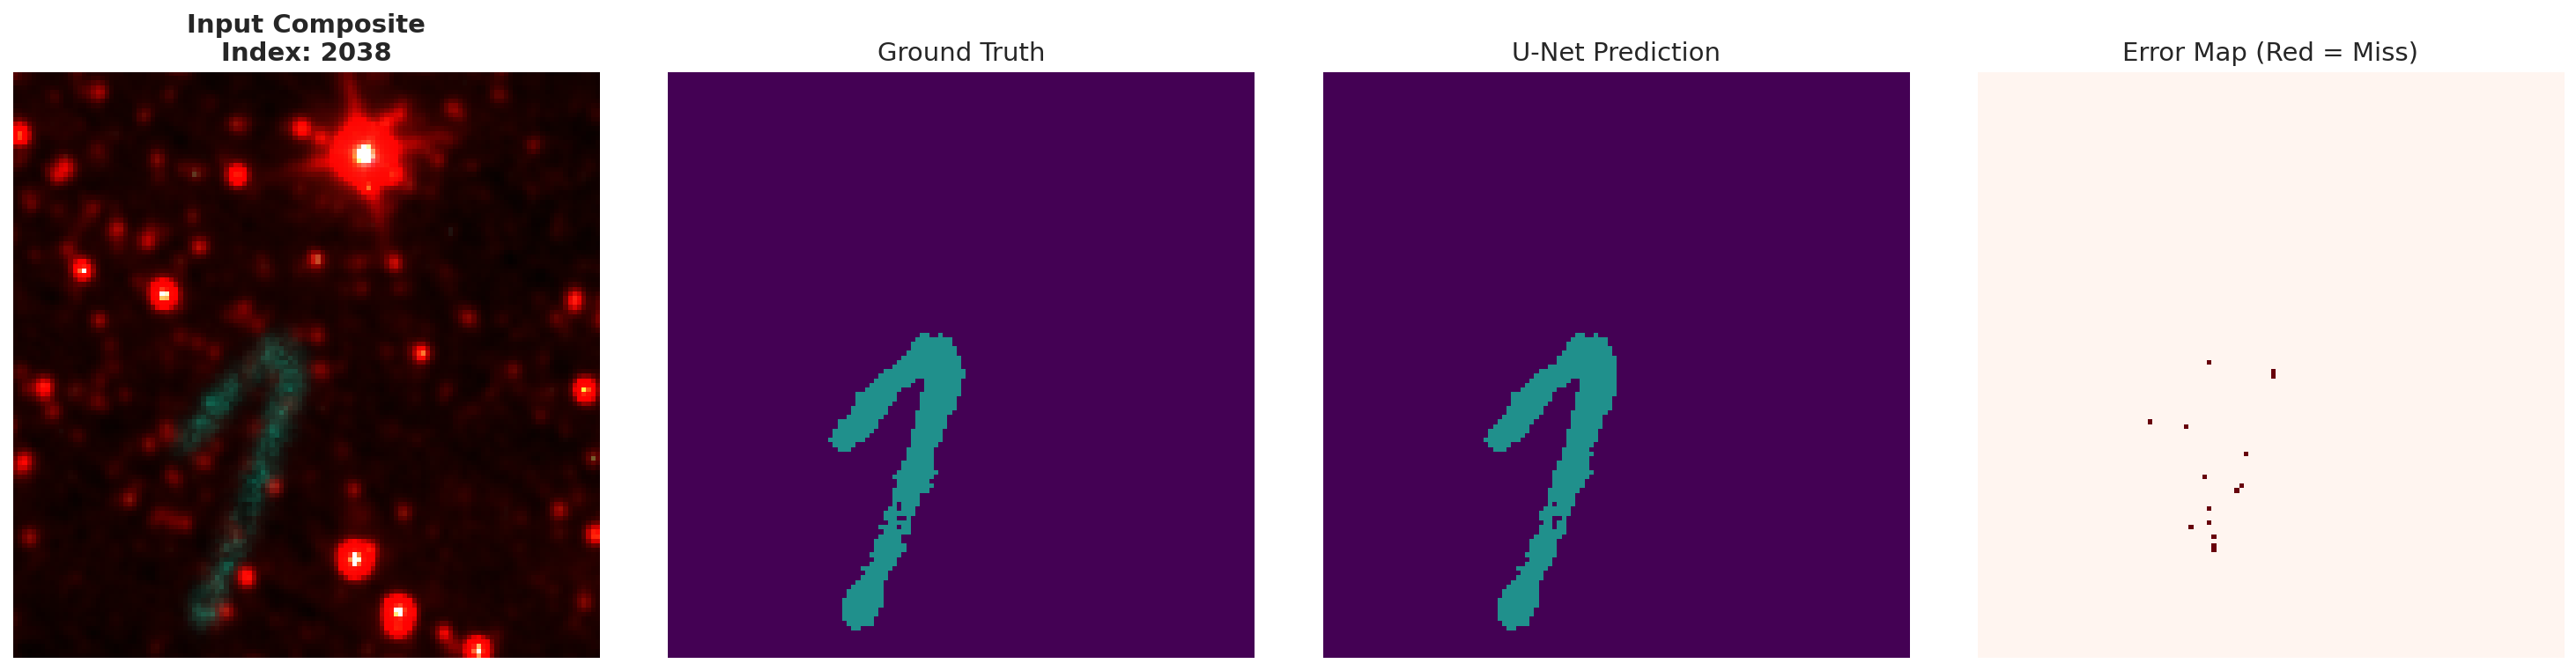

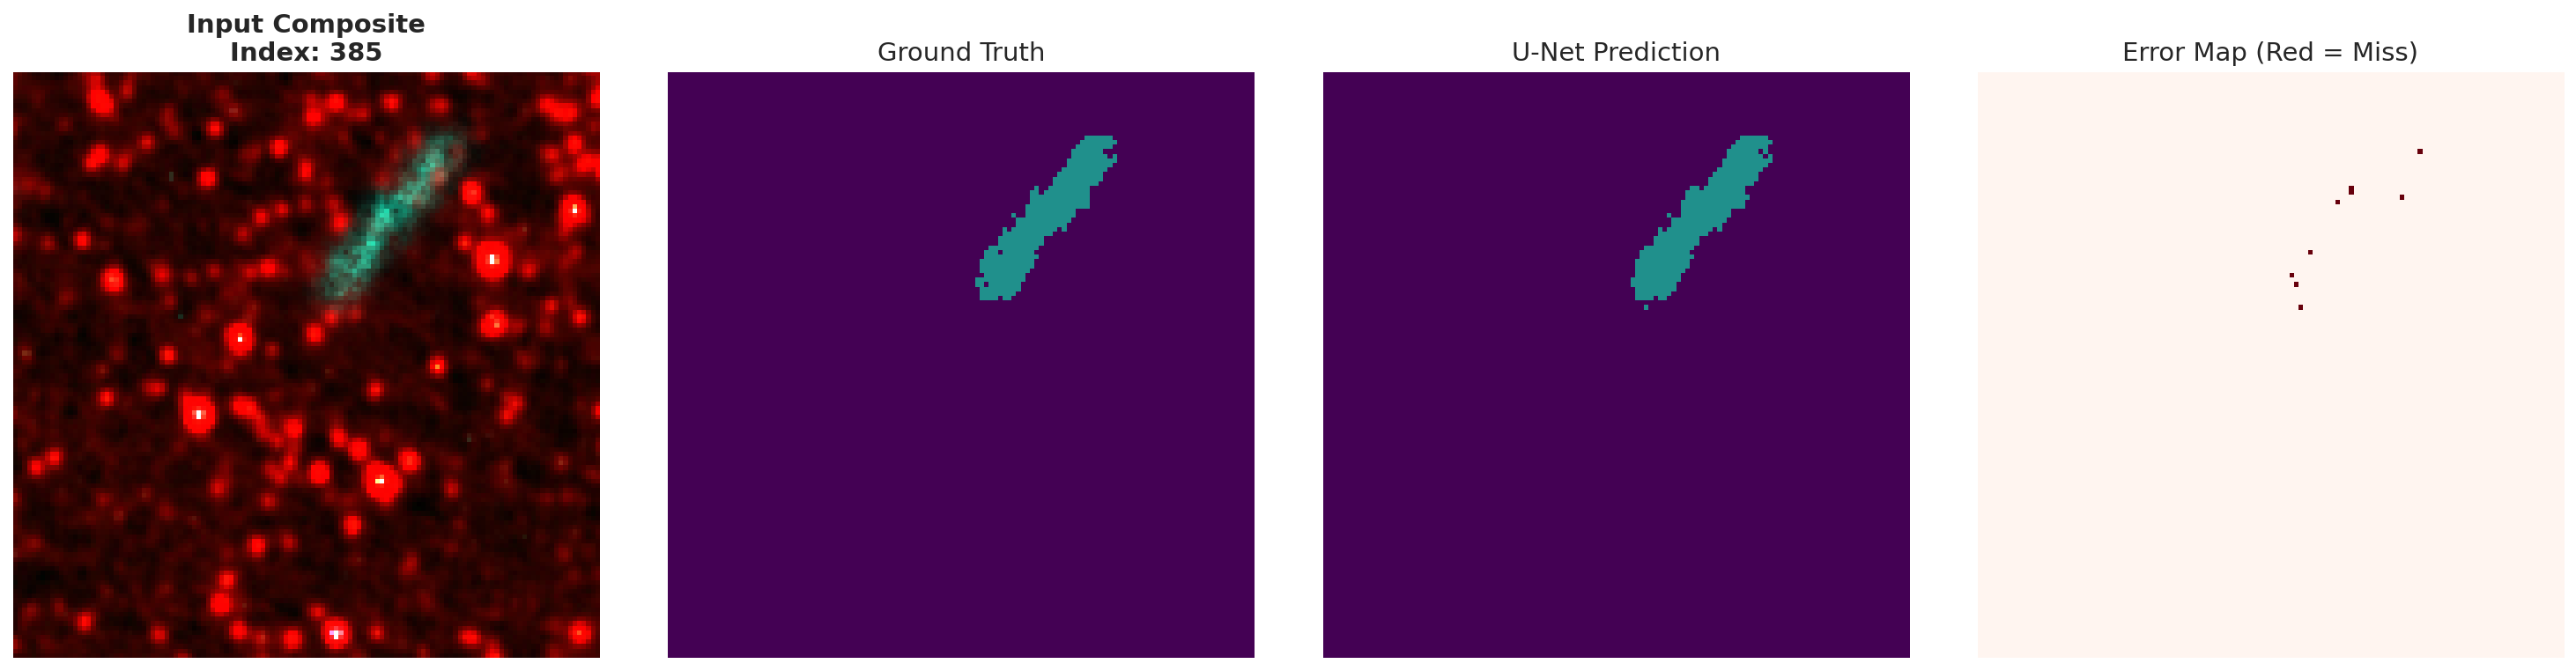

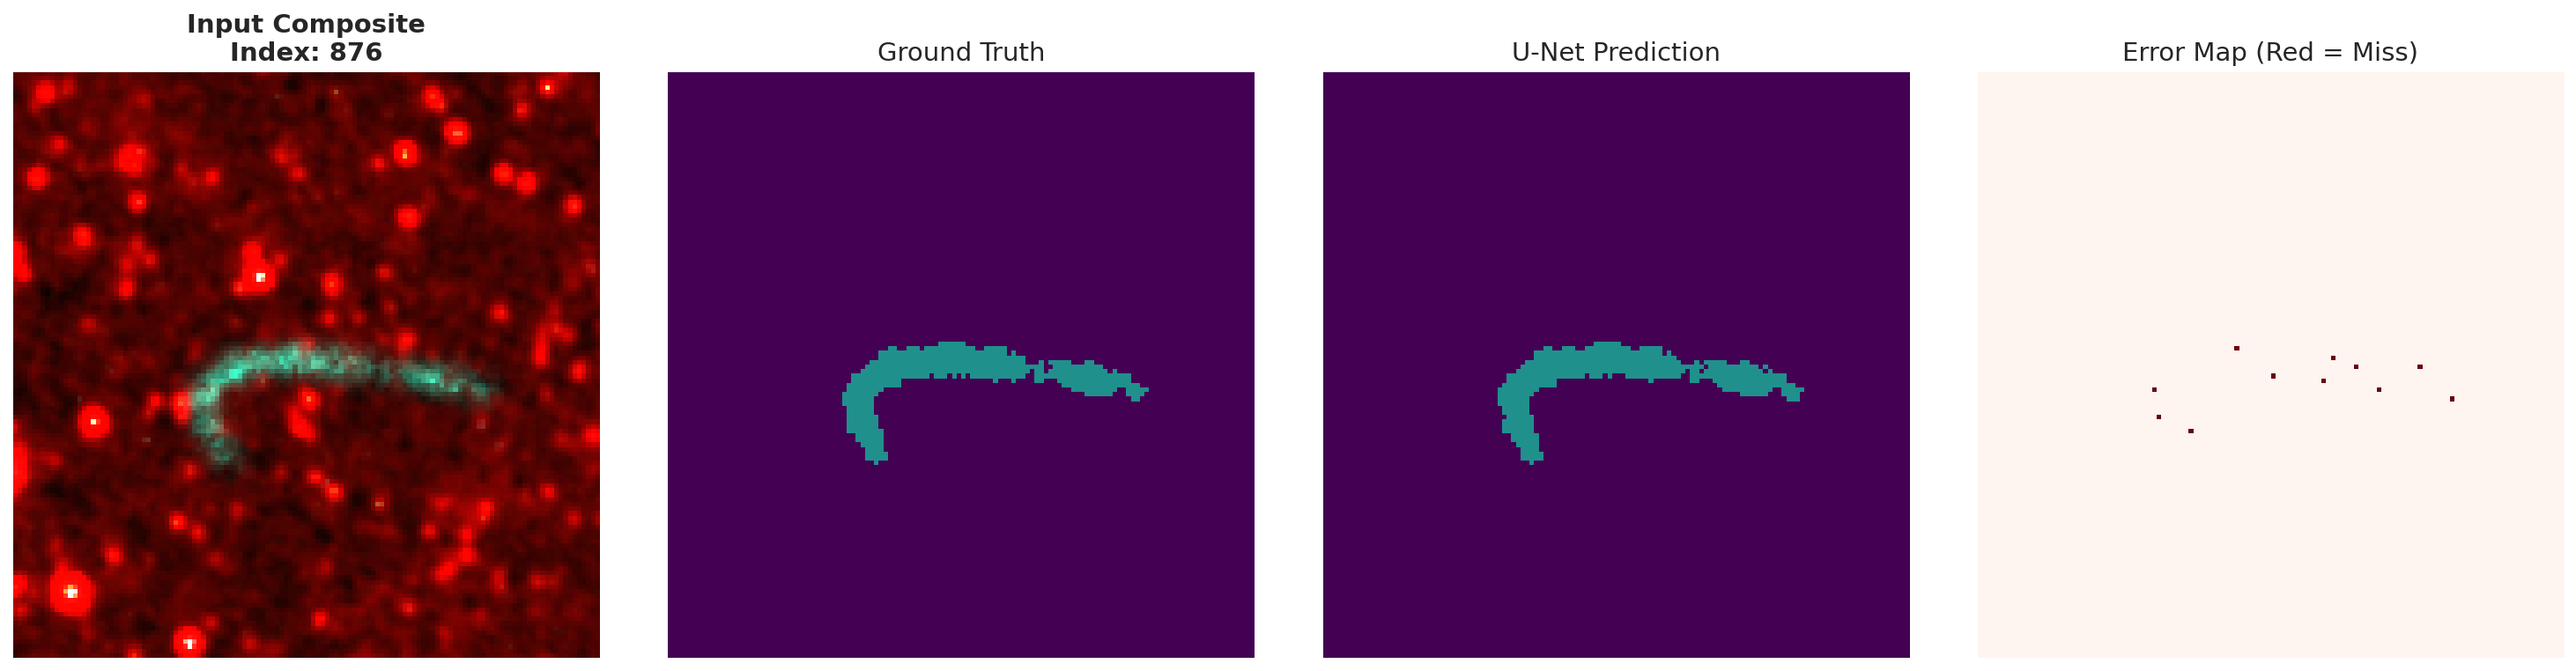


⚠️ TOP 3 HARD MINING CASES (Worst Performance Analysis):
Visual inspection of these cases is crucial for discussion in the thesis.


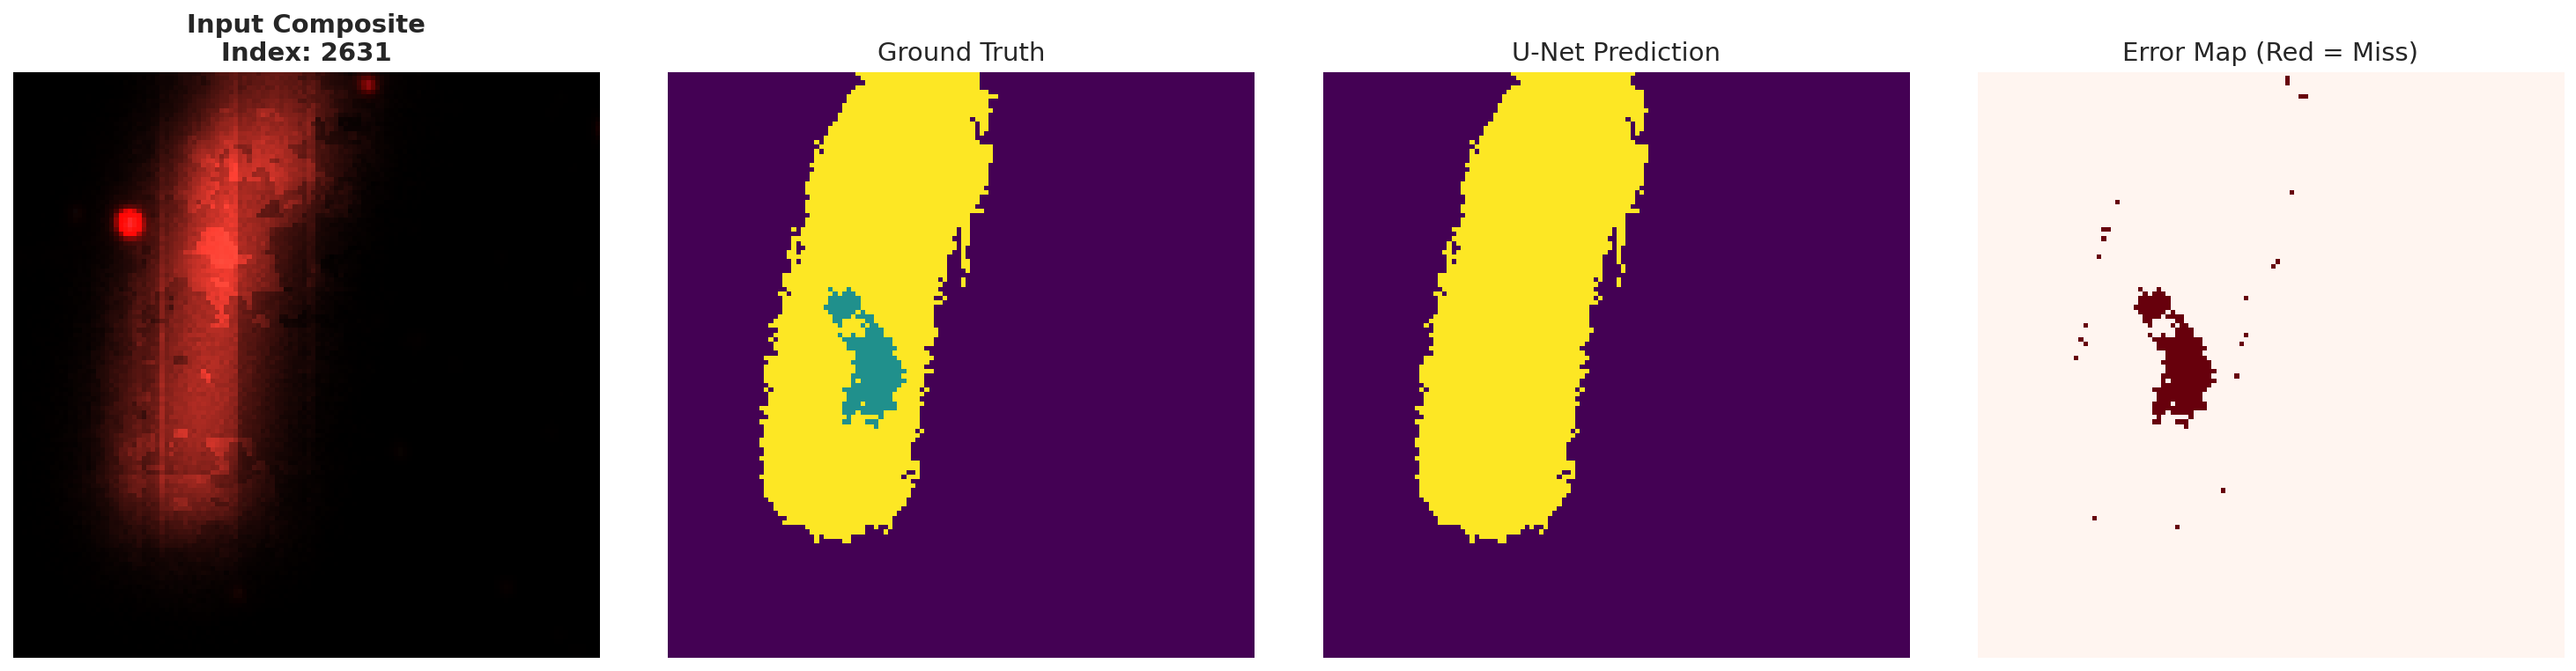

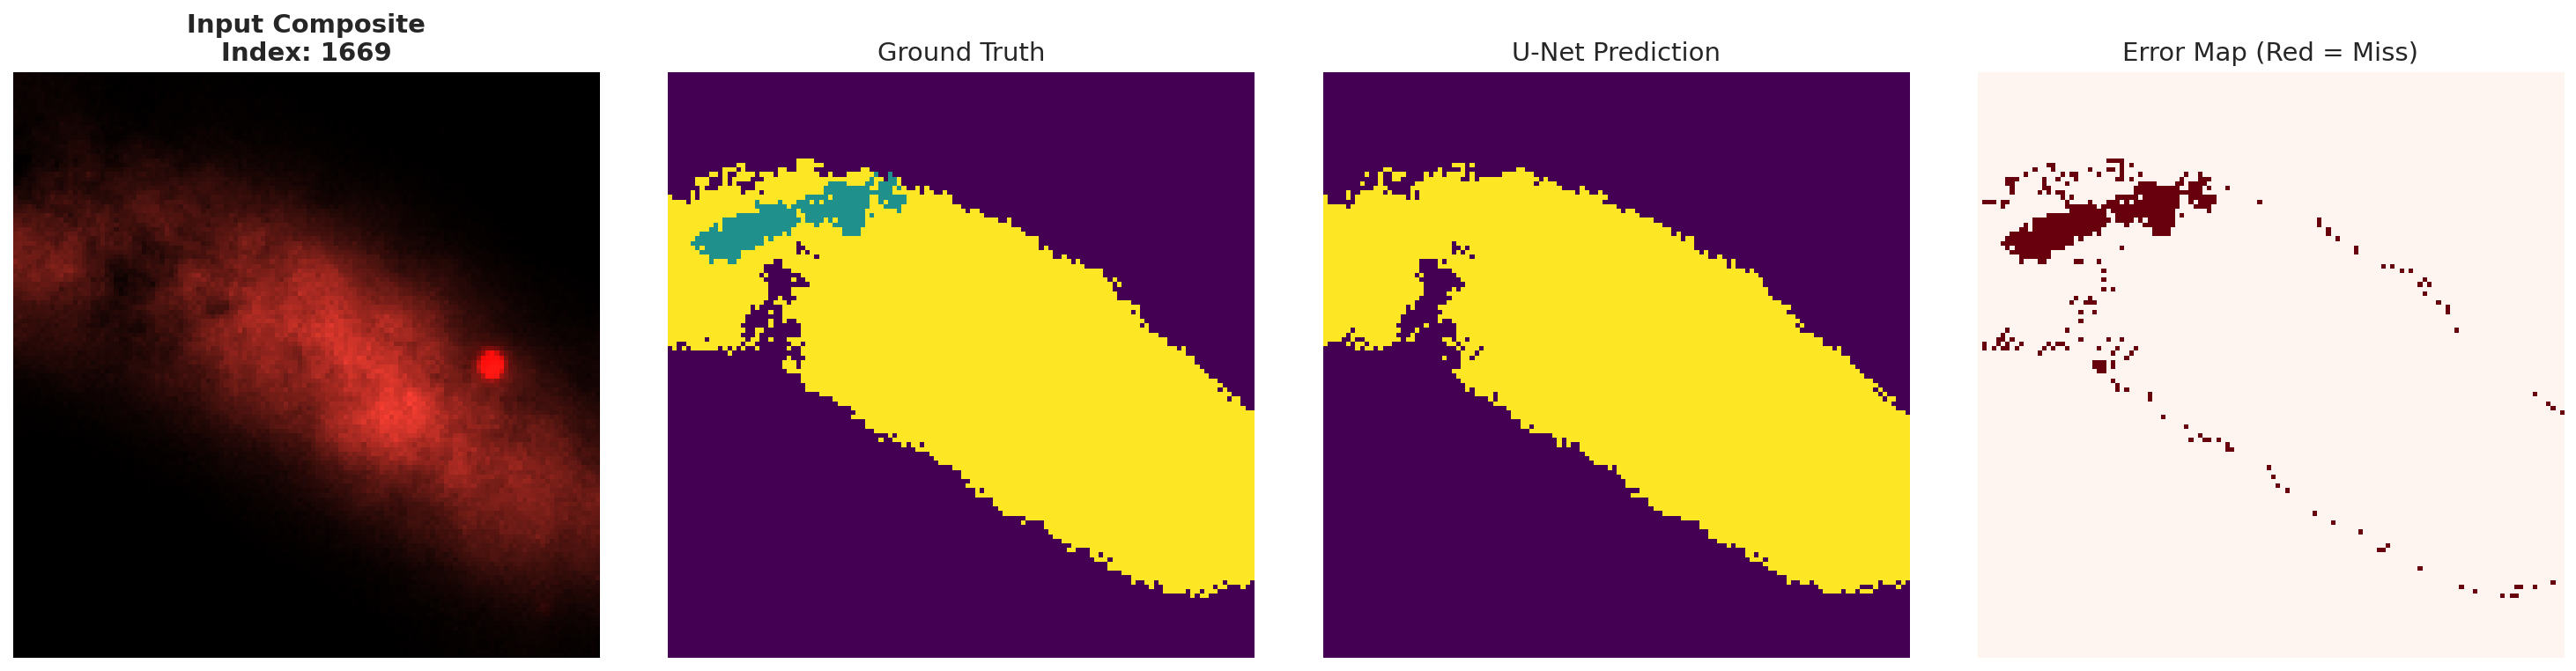

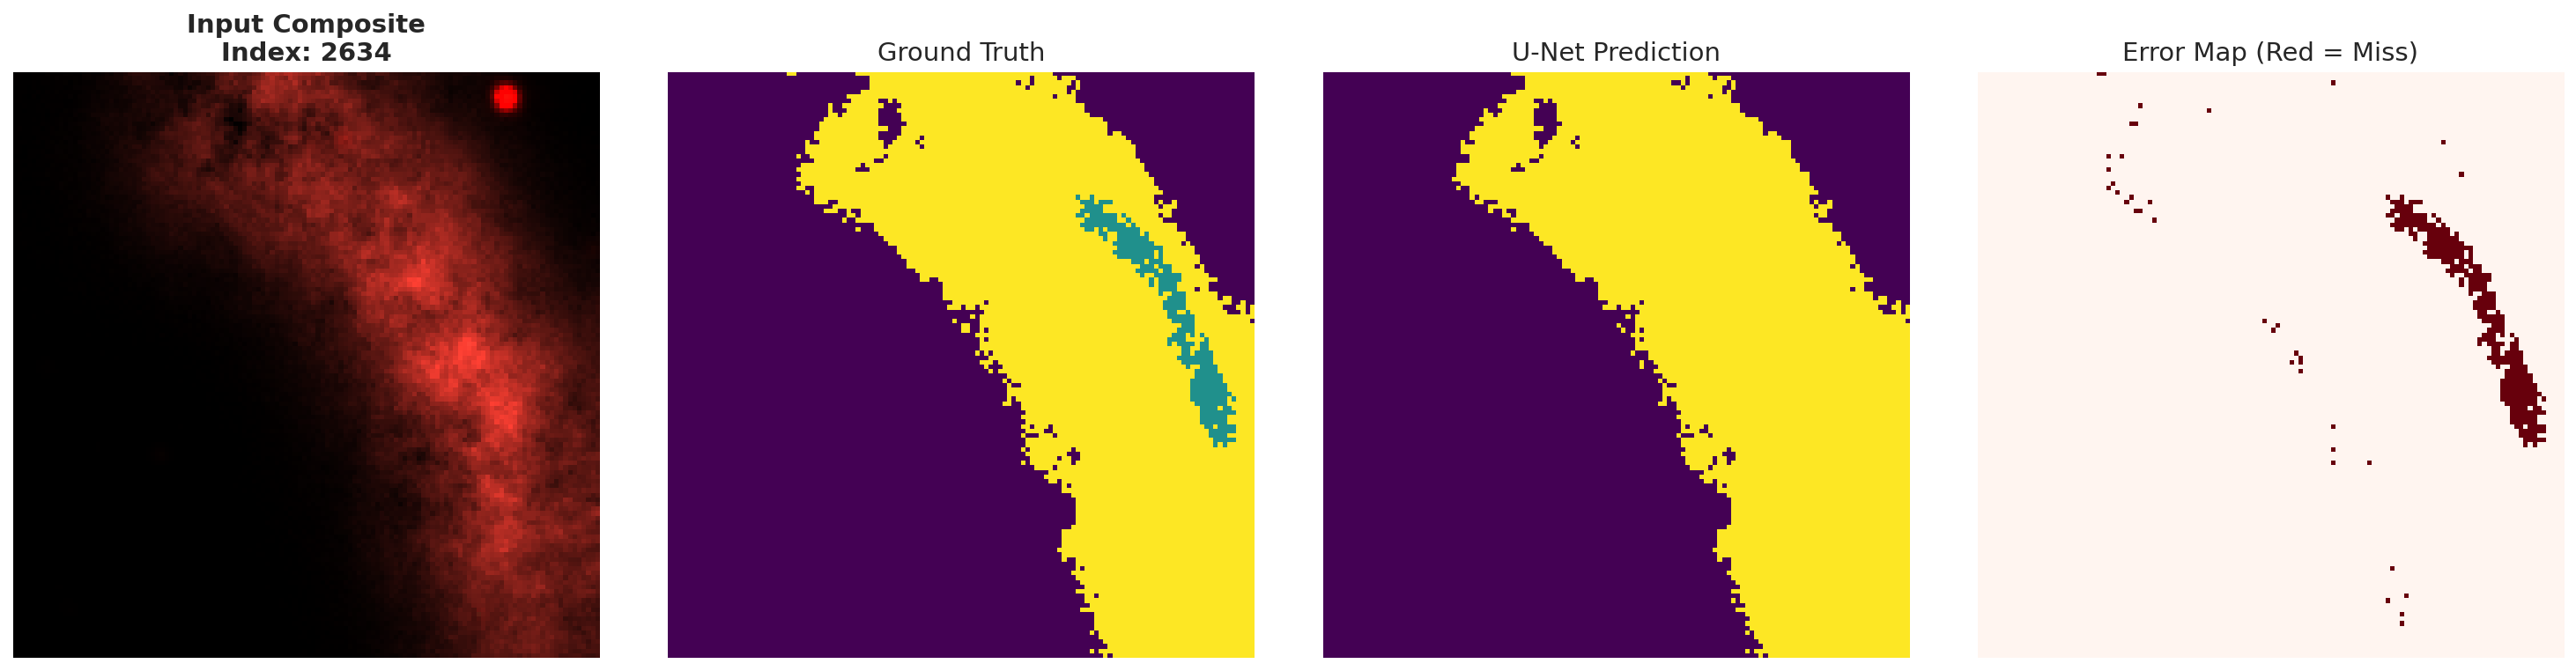

In [14]:
# ==========================================
# 7. QUALITATIVE ANALYSIS & HARD MINING
# ==========================================

def plot_prediction_panel(indices, title_prefix="Sample"):
    """
    Generates a scientific visualization panel for the selected samples.
    Shows: Input (Composite), Ground Truth, Prediction, and Error Map.
    """
    for idx in indices:
        fig, ax = plt.subplots(1, 4, figsize=(20, 5))
        
        # 1. False Color RGB Composite (Scientific Visualization)
        # Mapping: R=Cirrus(W1), G=Stream(r), B=Background(g)
        rgb = np.stack([X_test[idx,:,:,2], X_test[idx,:,:,1], X_test[idx,:,:,0]], axis=-1)
        rgb = (rgb - rgb.min())/(rgb.max()-rgb.min()+1e-6)
        
        ax[0].imshow(rgb)
        ax[0].set_title(f"Input Composite\nIndex: {idx}", fontweight='bold')
        
        # 2. Ground Truth
        ax[1].imshow(np.argmax(Y_test[idx], axis=-1), vmin=0, vmax=2, cmap='viridis')
        ax[1].set_title("Ground Truth")
        
        # 3. Prediction
        pred_mask = np.argmax(preds[idx], axis=-1)
        ax[2].imshow(pred_mask, vmin=0, vmax=2, cmap='viridis')
        ax[2].set_title("U-Net Prediction")
        
        # 4. Error Map
        gt_mask = np.argmax(Y_test[idx], axis=-1)
        error = (gt_mask != pred_mask)
        ax[3].imshow(error, cmap='Reds', vmin=0, vmax=1)
        ax[3].set_title("Error Map (Red = Miss)")
        
        for a in ax: a.axis('off')
        plt.tight_layout()
        plt.show()

# --- ANALYSIS STRATEGY ---

# 1. Compute Image-Level IoU for the 'Stream' Class
y_true_stream = Y_test[..., 1]
y_pred_stream = preds[..., 1]
intersection = np.sum(y_true_stream * y_pred_stream, axis=(1,2))
union = np.sum(y_true_stream, axis=(1,2)) + np.sum(y_pred_stream, axis=(1,2))
stream_iou = intersection / (union + 1e-6)

# Filter: Only analyze images containing actual streams (>50 pixels)
has_stream = np.sum(y_true_stream, axis=(1,2)) > 50
stream_indices = np.where(has_stream)[0]

if len(stream_indices) > 0:
    # Sort indices by Performance
    sorted_indices = stream_indices[np.argsort(stream_iou[stream_indices])]
    
    worst_cases = sorted_indices[:3]    # Lowest IoU
    best_cases = sorted_indices[-3:]    # Highest IoU

    print("🌟 TOP 3 BEST PREDICTIONS (High Fidelity Stream Recovery):")
    plot_prediction_panel(best_cases)

    print("\n⚠️ TOP 3 HARD MINING CASES (Worst Performance Analysis):")
    print("Visual inspection of these cases is crucial for discussion in the thesis.")
    plot_prediction_panel(worst_cases)
else:
    print("Note: Insufficient stream samples found in Test set for ranking.")